<a href="https://colab.research.google.com/github/LuisManuelCatzoliSoriano/Simulaci-n_II/blob/main/Clase_17_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

La siguiente ecuación diferencial estocástico correponde a un modelo de Vasicek para tasas de interés:

$$dx_t=c(x_t-u)dt+σdw_t$$

$dx_t$ es la tasa al tiempo $t$, $c=-0.9$, $u=5$, $σ=0.01$ y $x=4.9$.

$a)$ Usando el método de Euler-Murayama, simular una trayectoria para el proceso $x_t, x_0,x_1,...,x_{30}$ y graficarla.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

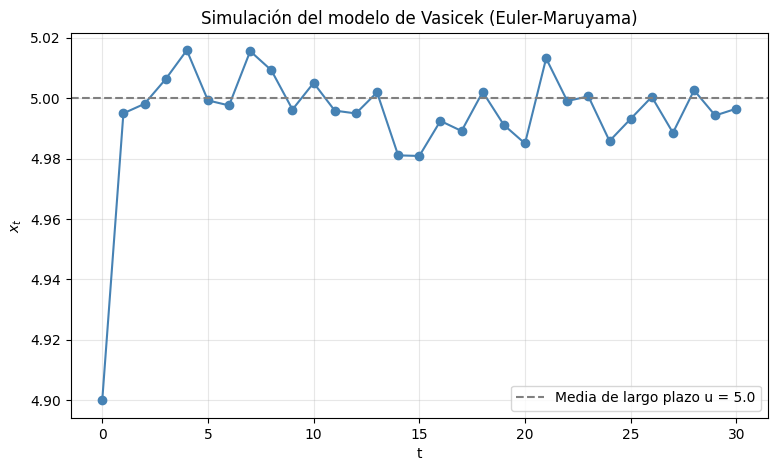

[4.9        4.99496714 4.99811407 5.00628829 5.01585913 4.99924438
 4.99758307 5.01555043 5.00922939 4.9962282  5.00504842 4.99587067
 4.99492977 5.0019126  4.98105846 4.98085667 4.99246279 4.98911797
 5.00205427 4.99112519 4.98498948 5.01315544 4.99905778 5.00058106
 4.98581062 4.99313724 5.00042295 4.98853236 5.00261022 4.99425463
 4.99650853]


In [20]:
# Parámetros del modelo
c = -0.9      # velocidad de reversión (con signo ya incluido)
u = 5.0       # media de largo plazo
sigma = 0.01  # volatilidad
x0 = 4.9      # valor inicial

# Parámetros de la simulación
N = 30        # número de pasos (x0, x1, ..., x30)
dt = 1.0      # tamaño del paso de tiempo
np.random.seed(42)  # para reproducibilidad (opcional, quítalo si quieres aleatoriedad real)

# Vector para guardar la trayectoria
x = np.zeros(N + 1)
x[0] = x0

# Simulación con Euler-Maruyama
for t in range(N):
    dW = np.random.normal(0, np.sqrt(dt))          # incremento browniano
    x[t+1] = x[t] + c * (x[t] - u) * dt + sigma * dW

# Graficar la trayectoria
tiempo = np.arange(0, N + 1) * dt

plt.figure(figsize=(9, 5))
plt.plot(tiempo, x, marker='o', linestyle='-', color='steelblue')
plt.axhline(u, color='gray', linestyle='--', label=f'Media de largo plazo u = {u}')
plt.title('Simulación del modelo de Vasicek (Euler-Maruyama)')
plt.xlabel('t')
plt.ylabel('$x_t$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(x)

$b)$ Crear el histograma para $x_{30}$.

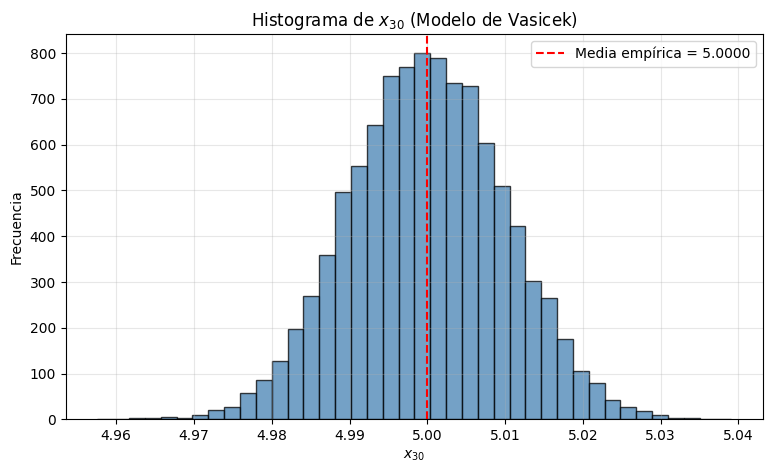

Media de x_30: 4.999966
Desviación estándar de x_30: 0.009960


In [12]:
M = 10000       # número de trayectorias simuladas

np.random.seed(42)

# Simulamos M trayectorias y guardamos solo x_30 de cada una
x30_values = np.zeros(M)

for i in range(M):
    x = x0
    for t in range(N):
        dW = np.random.normal(0, np.sqrt(dt))
        x = x + c * (x - u) * dt + sigma * dW
    x30_values[i] = x

# Histograma de x_30
plt.figure(figsize=(9, 5))
plt.hist(x30_values, bins=40, color='steelblue', edgecolor='black', alpha=0.75)
plt.axvline(np.mean(x30_values), color='red', linestyle='--',
            label=f'Media empírica = {np.mean(x30_values):.4f}')
plt.title('Histograma de $x_{30}$ (Modelo de Vasicek)')
plt.xlabel('$x_{30}$')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Media de x_30: {np.mean(x30_values):.6f}")
print(f"Desviación estándar de x_30: {np.std(x30_values):.6f}")

$c)$ Estimar la probabilidad de que $x_{30}>4.95$.

In [14]:
import numpy as np

In [15]:
# Usando las x30_values ya simuladas en el inciso b)
prob_estimada = np.mean(x30_values > 4.95)

print(f"P(x_30 > 4.95) ≈ {prob_estimada:.4f}")
print(f"Es decir, aproximadamente {prob_estimada*100:.2f}%")

P(x_30 > 4.95) ≈ 1.0000
Es decir, aproximadamente 100.00%


In [17]:
from scipy.stats import norm

In [18]:
T = 30
media_teorica = u + (x0 - u) * np.exp(c * T)
varianza_teorica = (sigma**2 / (2*abs(c))) * (1 - np.exp(2*c*T))
std_teorica = np.sqrt(varianza_teorica)

prob_teorica = 1 - norm.cdf(4.95, loc=media_teorica, scale=std_teorica)

print(f"Media teórica de x_30: {media_teorica:.6f}")
print(f"Desv. estándar teórica: {std_teorica:.6f}")
print(f"P(x_30 > 4.95) teórica ≈ {prob_teorica:.4f}")

Media teórica de x_30: 5.000000
Desv. estándar teórica: 0.007454
P(x_30 > 4.95) teórica ≈ 1.0000


$d)$ Estimar el tiempo en el que por primera vez $x_t$ sea mayor que $u$.

In [19]:
tiempos_cruce = []      # aquí guardamos el primer tiempo de cruce de cada trayectoria
no_cruzaron = 0         # contador de trayectorias que nunca llegan a superar u dentro de [0, N]

for i in range(M):
    x = x0
    cruzo = False
    for t in range(1, N + 1):
        dW = np.random.normal(0, np.sqrt(dt))
        x = x + c * (x - u) * dt + sigma * dW
        if x > u:
            tiempos_cruce.append(t)
            cruzo = True
            break
    if not cruzo:
        no_cruzaron += 1

tiempos_cruce = np.array(tiempos_cruce)

print(f"Trayectorias que cruzaron u dentro de [0,{N}]: {len(tiempos_cruce)} de {M}")
print(f"Trayectorias que NO cruzaron: {no_cruzaron}")
print(f"Tiempo promedio de primer cruce (entre las que cruzaron): {tiempos_cruce.mean():.4f}")
print(f"Mediana del tiempo de primer cruce: {np.median(tiempos_cruce):.4f}")

Trayectorias que cruzaron u dentro de [0,30]: 10000 de 10000
Trayectorias que NO cruzaron: 0
Tiempo promedio de primer cruce (entre las que cruzaron): 2.8549
Mediana del tiempo de primer cruce: 2.0000
